# Neural Posterior Estimation for LISA
## Part 1 — from one source to a catalog

**Tutorial by Max Dax, building on Stephen Green's
[LISAAI-Hackathon-ESTEC](https://github.com/stephengreen/LISAAI-Hackathon-ESTEC) tutorial**

Stephen's Part 2a ended with a strong result: a network trained once, on a narrow post-search
frequency prior, solved a prior twenty times wider with **no retraining**. Heterodyning the data
by a frequency guess turns each tile of the wide prior back into the narrow problem the network
already knows, so widening the prior added tiles, not training.

LISA will not hand us one galactic binary with a search already run: of order $10^4$ resolvable
binaries share the data stream. In this notebook we inject 40 sources into a single record
(loud, marginal, and genuinely undetectable ones) and run the same frozen network, from the same
checkpoint file, over all of it. The per-tile evidence becomes a detection statistic, the
detections become posteriors, and the posteriors become a catalog, scored against the injected
truth.

Two simplifications are carried over from Stephen's tutorial, and Part 2 lifts both: the noise is
white and Gaussian (the real background of unresolved binaries is neither), and the sky position
is fixed and known.

<!-- ---

### Roadmap (about 25 minutes)

| | | |
|---|---|---|
| 0 | What the data is | ~3 min |
| 1 | A population in one data stream | ~3 min |
| 2 | The scan, made $W$-independent | ~5 min |
| 3 | Detection: from evidence to candidates | ~4 min |
| 4 | The catalog | ~5 min |
| 5 | Completeness, and the resolvability limit | ~4 min |
| 6 | Exercises, and what Part 2 must repair | remainder |

-->

`gb_simulator.py` and `gb_wide.py` are vendored verbatim from Stephen's repository (MIT), and
`checkpoints/part1_flow_v2.pt` is his Part 1 network, byte for byte. The new pieces live in
`gb_catalog.py`: the population, the scan, detection, and the catalog machinery.

In [1]:
# Guarded so that this is a no-op where the packages already exist (e.g. a uv-managed venv);
# on a bare Colab runtime it installs.
import importlib.util
import sys

if any(importlib.util.find_spec(pkg) is None for pkg in ("glasflow", "corner")):
    !{sys.executable} -m pip install -q glasflow corner

In [2]:
# On Colab, fetch the tutorial modules and the frozen network. No-op from a repo clone.
import os
import urllib.request

REPO_RAW = "https://github.com/max-dax/LISAI-2026-GB-tutorial/raw/main"  # adjust if forked
for f in ["gb_simulator.py", "gb_wide.py", "gb_catalog.py", "checkpoints/part1_flow_v2.pt"]:
    if not os.path.exists(f):
        os.makedirs(os.path.dirname(f) or ".", exist_ok=True)
        urllib.request.urlretrieve(f"{REPO_RAW}/{f}", f)

In [3]:
import time

import corner
import matplotlib.pyplot as plt
import numpy as np
import torch

import gb_simulator as gb
import gb_wide as gbw
import gb_catalog as gbc
from gb_simulator import N, device
from gb_wide import DF_P1

print(f"device: {device}")

device: cpu


---
# 0. What the data is

<!-- *(~3 min)* -->

If you have not worked with LISA data before, one convention needs spelling out, because the
frequency axes below run from $-100$ to $+100\,\mu$Hz and that looks odd at first.

A galactic binary near 3 mHz completes about 380,000 cycles in a four-year observation. A time
series resolving that carrier would need tens of millions of samples, and almost nothing in it is
interesting: all the physics sits in slow modulations of a nearly monochromatic tone. So the
first processing step is to **heterodyne**: multiply the strain by $e^{-2\pi i F_{\rm ref} t}$
with $F_{\rm ref} = 3$ mHz, which shifts a source at $f_0 = F_{\rm ref} + \delta f$ down to the
offset frequency $\delta f$, then low-pass and downsample. What survives is the **complex
envelope**: a time series of 51,200 complex samples, one every 41 minutes, carrying the same
information about our sources as the raw record.

This envelope is the simulator's native format; the carrier never appears in the code. Three
consequences:

- The data vector is the envelope's real and imaginary parts, $2 \times 51{,}200$ numbers.
- Frequencies are quoted as offsets $\delta f$ from 3 mHz, so the physical band is 2.9 to
  3.1 mHz. Because the envelope is complex, its spectrum is not symmetric: negative and positive
  offsets are genuinely different frequencies.
- The noise is white with unit variance per sample. The data is assumed whitened; Part 2
  revisits this assumption.

Heterodyning then enters a *second* time, as the method under study: the scan multiplies the
envelope by $e^{-2\pi i \widehat{\delta f} t}$ for each tile's guess $\widehat{\delta f}$,
re-centering that tile at zero frequency and discarding the bandwidth this frees up. In summary:

| step | band | representation |
|---|---|---|
| raw strain (never simulated) | carrier near 3 mHz | real time series, $\sim 10^7$ samples |
| heterodyne by $F_{\rm ref}$, assumed done upstream | $\pm 100\,\mu$Hz | complex envelope, 51,200 samples |
| heterodyne by $\widehat{\delta f}$, once per tile | $\pm 1.01\,\mu$Hz | complex envelope, 256 samples: the network input |

The network reads the last row as a time series. The plots below show spectra instead, because
forty narrowband sources are invisible in the time domain and are spikes in the frequency domain;
with white noise and a unitary FFT the two views carry identical information.

---
# 1. A population in one data stream

<!-- *(~3 min)* -->

The knobs of the experiment live in one dataclass, so the notebook can be re-run as a different
mission. The defaults: a widening factor $W = 1000$, i.e.
$\delta f \sim \mathcal{U}[\pm 100\,\mu{\rm Hz}]$, fifty times the prior of Part 2a and two
thousand tiles, with 40 binaries dropped in at random frequencies.

The amplitude range reaches below the network's prior floor of $A = 1.4$ (SNR about 6). Sources
fainter than that cannot even be represented by the model; they stand in for the population a
real catalog must leave behind, and in Part 2 their thousands of siblings become the confusion
background itself.

Keep the geometry in mind: the mean spacing between sources is about $5\,\mu$Hz, against a
retained band of $\pm 1.01\,\mu$Hz per tile. Most sources are alone in their band. Some are not,
and we keep those deliberately, because they mark where the single-source model ends.

In [4]:
settings = gbc.CatalogSettings(w=1000, n_sources=40, amp_low=0.5, amp_high=7.0, seed=42)
K = gbc.configure(settings)

theta_true = gbc.sample_population(settings)     # sorted by frequency
snr_true = gbc.snr(theta_true)
d = gbc.observe(theta_true, seed=1)

f_true = theta_true[:, 1]
gap = (f_true[:, None] - f_true[None, :]).abs() + torch.eye(len(f_true), device=device)
n_close = int((gap.min(-1).values < 1.01e-6).sum())
print(f"{K} tiles of {2e9 * gbw.TILE_HALF:.0f} nHz over ±{settings.w * DF_P1 * 1e6:.0f} uHz; "
      f"{2 * gbw.N_WIDE} data features")
print(f"{settings.n_sources} sources, SNR {snr_true.min():.1f} .. {snr_true.max():.1f} "
      f"(median {snr_true.median():.1f}); {int((theta_true[:, 0] < 1.4).sum())} below the "
      f"network's prior floor")
print(f"{n_close} sources have a neighbor inside their retained band")

2000 tiles of 100 nHz over ±100 uHz; 102400 data features
40 sources, SNR 3.7 .. 70.9 (median 24.3); 9 below the network's prior floor
20 sources have a neighbor inside their retained band


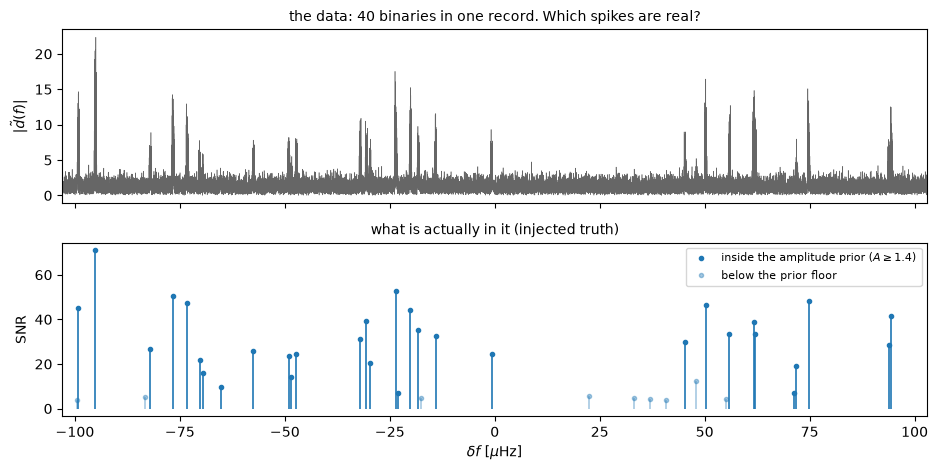

In [5]:
DT_WIDE = (gbw.t_wide[1] - gbw.t_wide[0]).item()
f_axis = np.fft.fftshift(np.fft.fftfreq(gbw.N_WIDE, d=DT_WIDE)) * 1e6
z = torch.complex(d[:gbw.N_WIDE], d[gbw.N_WIDE:]).cpu().numpy()
spec_data = np.abs(np.fft.fftshift(np.fft.fft(z))) / np.sqrt(gbw.N_WIDE)

fig, axes = plt.subplots(2, 1, figsize=(9.5, 4.8), sharex=True)
axes[0].plot(f_axis, spec_data, lw=0.4, color="0.4")
axes[0].set_ylabel(r"$|\tilde d(f)|$")
axes[0].set_title(f"the data: {settings.n_sources} binaries in one record. "
                  "Which spikes are real?", fontsize=10)

vis = (theta_true[:, 0] >= 1.4).cpu()
for m, label, alpha in [(vis, r"inside the amplitude prior ($A \geq 1.4$)", 1.0),
                        (~vis, "below the prior floor", 0.4)]:
    axes[1].vlines(f_true[m].cpu() * 1e6, 0, snr_true[m].cpu(), color="C0", lw=1.2, alpha=alpha)
    axes[1].plot(f_true[m].cpu() * 1e6, snr_true[m].cpu(), "o", color="C0", ms=3, alpha=alpha,
                 label=label)
axes[1].set_xlim(-103, 103)
axes[1].set_xlabel(r"$\delta f\ [\mu{\rm Hz}]$"); axes[1].set_ylabel("SNR")
axes[1].set_title("what is actually in it (injected truth)", fontsize=10)
axes[1].legend(fontsize=8)
plt.tight_layout()

---
# 2. The scan, made $W$-independent

<!-- *(~5 min)* -->

The machinery is Part 2a's, unchanged: demodulate the record by each tile's proxy
$\widehat{\delta f}$, keep the central $N$ frequency bins, and hand the frozen network a data
vector distributed exactly like its training data. Two checks before trusting this at
$W = 1000$: the conditioned signal still matches Part 1's, and unit noise still comes out unit.

In [6]:
th = gb.sample_prior(64)
th[:, 1] = (torch.rand(64, device=device) - 0.5) * 2 * gbw.TILE_HALF
th_shift = th.clone()
th_shift[:, 1] = th_shift[:, 1] + gbw.DF_HAT[K // 3]
err = ((gbw.condition(gbw.signal_wide(th_shift), gbw.DF_HAT[K // 3]) - gb.signal(th))
       .pow(2).sum(-1).sqrt() / gb.signal(th).pow(2).sum(-1).sqrt())
noise_sd = gbw.condition(torch.randn(500, 2 * gbw.N_WIDE, device=device),
                         gbw.DF_HAT[K // 3]).std()
print(f"signal error after conditioning: median {err.median():.4f}, max {err.max():.4f}")
print(f"conditioned noise sd:            {noise_sd:.4f}")

signal error after conditioning: median 0.0302, max 0.0480
conditioned noise sd:            1.0030


Part 2a importance-sampled every tile against the exact likelihood on the *full* record, whose
length grows with $W$; its section 6 flagged the consequence and sketched the fix, which we now
implement. The scan's likelihood is **band-limited**: evaluated on the same $2N$ conditioned
features the network reads, so the cost per tile does not depend on $W$. The exact likelihood is
not gone; it returns in section 4, for the handful of tiles that matter.

One piece of bookkeeping does real work. All weights are computed relative to the noise-only
likelihood,
$$
\log \mathcal{L}(d \mid \theta) - \log \mathcal{L}(d \mid \varnothing)
  \;=\; \langle d, s(\theta) \rangle - \tfrac{1}{2} \lVert s(\theta) \rVert^2 ,
$$
so the large constant $-\tfrac{1}{2}\lVert d \rVert^2$ cancels analytically, and the mean weight
in tile $k$ directly estimates the **Bayes factor** $B_k$ for *one source in this tile* against
*no source there*, with the prior volume, and hence the Occam penalty, already priced in.
Part 2a's evidence curve located one source; the same curve over crowded data is a search.

In [7]:
flow = gbc.load_part1_flow("checkpoints/part1_flow_v2.pt")

t0 = time.time()
d_cond = gbc.condition_all(d)                    # (K, 2N): every tile's view of the record
result = gbc.scan(flow, d_cond, n_draws=512)
t_scan = time.time() - t0
print(f"{K} tiles in {t_scan:.1f} s ({1e3 * t_scan / K:.0f} ms per tile), {2 * N} features "
      f"each; the {2 * gbw.N_WIDE}-feature record is never handed to anything")

2000 tiles in 39.9 s (20 ms per tile), 512 features each; the 102400-feature record is never handed to anything


Where to put the threshold? Run the identical pipeline on a record containing nothing. The
largest $\ln B_k$ that pure noise produces across two thousand tiles is what a false alarm looks
like; two nats above that is our threshold. This costs one extra scan, and it calibrates the
entire pipeline, network quirks included, rather than an idealized statistic.

noise-only scan: max ln B = -0.3 over 2000 tiles -> threshold 1.7


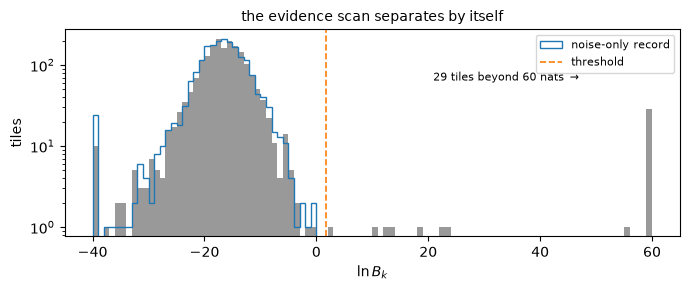

In [8]:
torch.manual_seed(2)
noise_record = gb.NOISE_STD * torch.randn(2 * gbw.N_WIDE, device=device)
log_B_noise = gbc.scan(flow, gbc.condition_all(noise_record), n_draws=512)["log_B"]
THRESHOLD = log_B_noise.max().item() + 2.0
print(f"noise-only scan: max ln B = {log_B_noise.max():.1f} over {K} tiles "
      f"-> threshold {THRESHOLD:.1f}")

log_B = result["log_B"].cpu().numpy()
ok = np.isfinite(log_B)
n_off = int((log_B[ok] > 60).sum())

plt.figure(figsize=(7, 3))
plt.hist(np.clip(log_B[ok], -40, 60), bins=100, range=(-40, 60), color="0.6", log=True)
plt.hist(np.clip(log_B_noise.cpu().numpy(), -40, 60), bins=100, range=(-40, 60),
         histtype="step", color="C0", log=True, label="noise-only record")
plt.axvline(THRESHOLD, color="C1", ls="--", lw=1.2, label="threshold")
plt.annotate(f"{n_off} tiles beyond 60 nats " r"$\rightarrow$", (0.72, 0.75),
             xycoords="axes fraction", fontsize=8, ha="center")
plt.xlabel(r"$\ln B_k$"); plt.ylabel("tiles")
plt.title("the evidence scan separates by itself", fontsize=10)
plt.legend(fontsize=8); plt.tight_layout()

---
# 3. Detection: from evidence to candidates

<!-- *(~4 min)* -->

Above-threshold tiles are grouped into candidates (a source near a tile boundary, or a very loud
one, can light two adjacent tiles), and each candidate is matched to the nearest injected source
among its tiles. The matching is only for scoring; the pipeline itself never sees the truth. Then
the picture this notebook exists for: the data, what was hidden in it, and what one frozen
network recovered.

In [9]:
candidates = gbc.detect(result["log_B"], THRESHOLD)
detected = gbc.match_candidates(candidates, theta_true)
false_alarms = [c for c in candidates if c["matched"] is None]
missed = ~detected

print(f"{len(candidates)} candidates: {int(detected.sum())} of {settings.n_sources} sources "
      f"detected, {len(false_alarms)} false alarms")
if missed.any():
    print(f"missed: SNR {sorted(round(s, 1) for s in snr_true[missed].tolist())}")

33 candidates: 33 of 40 sources detected, 0 false alarms
missed: SNR [3.7, 3.9, 4.5, 4.6, 4.8, 5.4, 5.7]


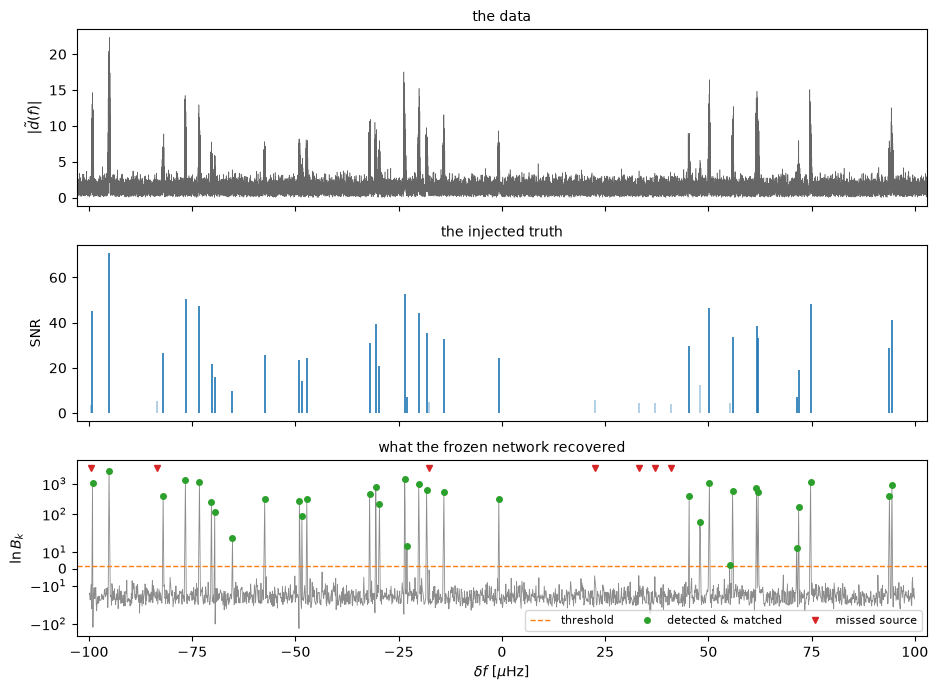

In [10]:
proxy = gbw.DF_HAT.cpu().numpy() * 1e6
fig, axes = plt.subplots(3, 1, figsize=(9.5, 7.0), sharex=True)

axes[0].plot(f_axis, spec_data, lw=0.4, color="0.4")
axes[0].set_ylabel(r"$|\tilde d(f)|$")
axes[0].set_title("the data", fontsize=10)

for m, alpha in [(vis, 1.0), (~vis, 0.4)]:
    axes[1].vlines(f_true[m].cpu() * 1e6, 0, snr_true[m].cpu(), color="C0", lw=1.2, alpha=alpha)
axes[1].set_ylabel("SNR")
axes[1].set_title("the injected truth", fontsize=10)

axes[2].plot(proxy[ok], log_B[ok], lw=0.6, color="0.55")
axes[2].axhline(THRESHOLD, color="C1", ls="--", lw=1.0, label="threshold")
k_det = [c["k_peak"] for c in candidates if c["matched"] is not None]
axes[2].plot(proxy[k_det], log_B[k_det], "o", color="C2", ms=4, label="detected & matched")
if false_alarms:
    k_fa = [c["k_peak"] for c in false_alarms]
    axes[2].plot(proxy[k_fa], log_B[k_fa], "x", color="C3", ms=6, label="false alarm")
if missed.any():
    axes[2].plot(f_true[missed].cpu() * 1e6, np.full(int(missed.sum()), np.nanmax(log_B[ok]) * 1.2),
                 "v", color="C3", ms=5, label="missed source")
axes[2].set_yscale("symlog", linthresh=20)
axes[2].set_xlim(-103, 103)
axes[2].set_xlabel(r"$\delta f\ [\mu{\rm Hz}]$"); axes[2].set_ylabel(r"$\ln B_k$")
axes[2].set_title("what the frozen network recovered", fontsize=10)
axes[2].legend(fontsize=8, loc="lower right", ncol=4)
plt.tight_layout()

Read the panels top to bottom: the spikes in the data, the population that produced them, and
the evidence curve that recovered it. Every recovered peak sits on an injected source; the
sources that are gone were drawn near or below the model's floor. Nothing about having forty
sources instead of one required a new method, because each tile only ever sees its own
$\pm 1\,\mu$Hz of the world.

---
# 4. The catalog

<!-- *(~5 min)* -->

The scan used the cheap band-limited likelihood to find candidates. For the survivors, a few
dozen tiles out of two thousand, we can afford Part 2a's full treatment again: the frozen
network's samples, importance-weighted against the **exact** likelihood on the complete record,
stitched across each candidate's tiles, with the sample efficiency $\epsilon$ attached as the
per-event verdict on the proposal. A cheap statistic selects, the exact likelihood verifies; this
keeps the correctness of the catalog independent of every approximation the search made.

(About three seconds per candidate on a laptop CPU; this is the most expensive cell in the
notebook.)

In [11]:
t0 = time.time()
catalog = []
for c in candidates:
    samples, info = gbc.stitched_posterior(flow, d, c, n_per_tile=8000)
    med = samples.median(0).values
    catalog.append({"cand": c, "samples": samples, "eps": info["eps"],
                    "f": med[1].item(), "sig_f": samples[:, 1].std().item(),
                    "A": med[0].item(), "snr": gbc.snr(med[None])[0].item()})
print(f"{len(catalog)} posteriors in {time.time() - t0:.0f} s\n")

print(f"{'':>5} {'f [uHz]':>10} {'sig_f [nHz]':>12} {'A':>6} {'SNR':>6} {'ln B':>8} "
      f"{'eps':>7}   {'truth (SNR)':>11}")
for i, row in enumerate(catalog):
    m = row["cand"]["matched"]
    truth = f"{snr_true[m]:11.1f}" if m is not None else f"{'—':>11}"
    print(f"GB{i:03d} {row['f'] * 1e6:10.3f} {row['sig_f'] * 1e9:12.2f} {row['A']:6.2f} "
          f"{row['snr']:6.1f} {row['cand']['log_B']:8.1f} {row['eps']:7.1%}   {truth}")

33 posteriors in 119 s

         f [uHz]  sig_f [nHz]      A    SNR     ln B     eps   truth (SNR)
GB000    -99.172         0.38   5.69   46.0   1048.7    1.8%          45.1
GB001    -95.105         0.23   6.48   73.6   2673.0    3.0%          70.9
GB002    -82.082         0.62   3.55   28.2    379.5   10.4%          26.6
GB003    -76.629         0.33   6.04   51.0   1284.9    0.7%          50.4
GB004    -73.283         0.36   5.78   47.5   1109.0    2.5%          47.2
GB005    -70.313         0.65   2.50   22.8    244.7   11.0%          21.7
GB006    -69.551         0.64   2.37   15.6    113.3    0.7%          15.8
GB007    -65.275         1.27   1.54    7.9     18.6    0.3%           9.8
GB008    -57.493         0.68   5.09   25.4    308.4   25.8%          25.7
GB009    -49.047         0.72   2.54   23.8    271.8   10.6%          23.5
GB010    -48.427         1.11   1.71   14.2     85.7    0.2%          14.1
GB011    -47.228         0.35   2.46   25.2    303.9    1.2%          24.3
G

A full posterior stands behind every row. Below, two of them against the injected truth: the
loudest catalog entry and the faintest. The loud posterior is a needle. The faint one deserves a
closer look: this source was injected from *below* the network's amplitude floor and caught at
the detection threshold, so its amplitude posterior piles up against the prior edge. That is what
a posterior should do for a source the model can barely express.

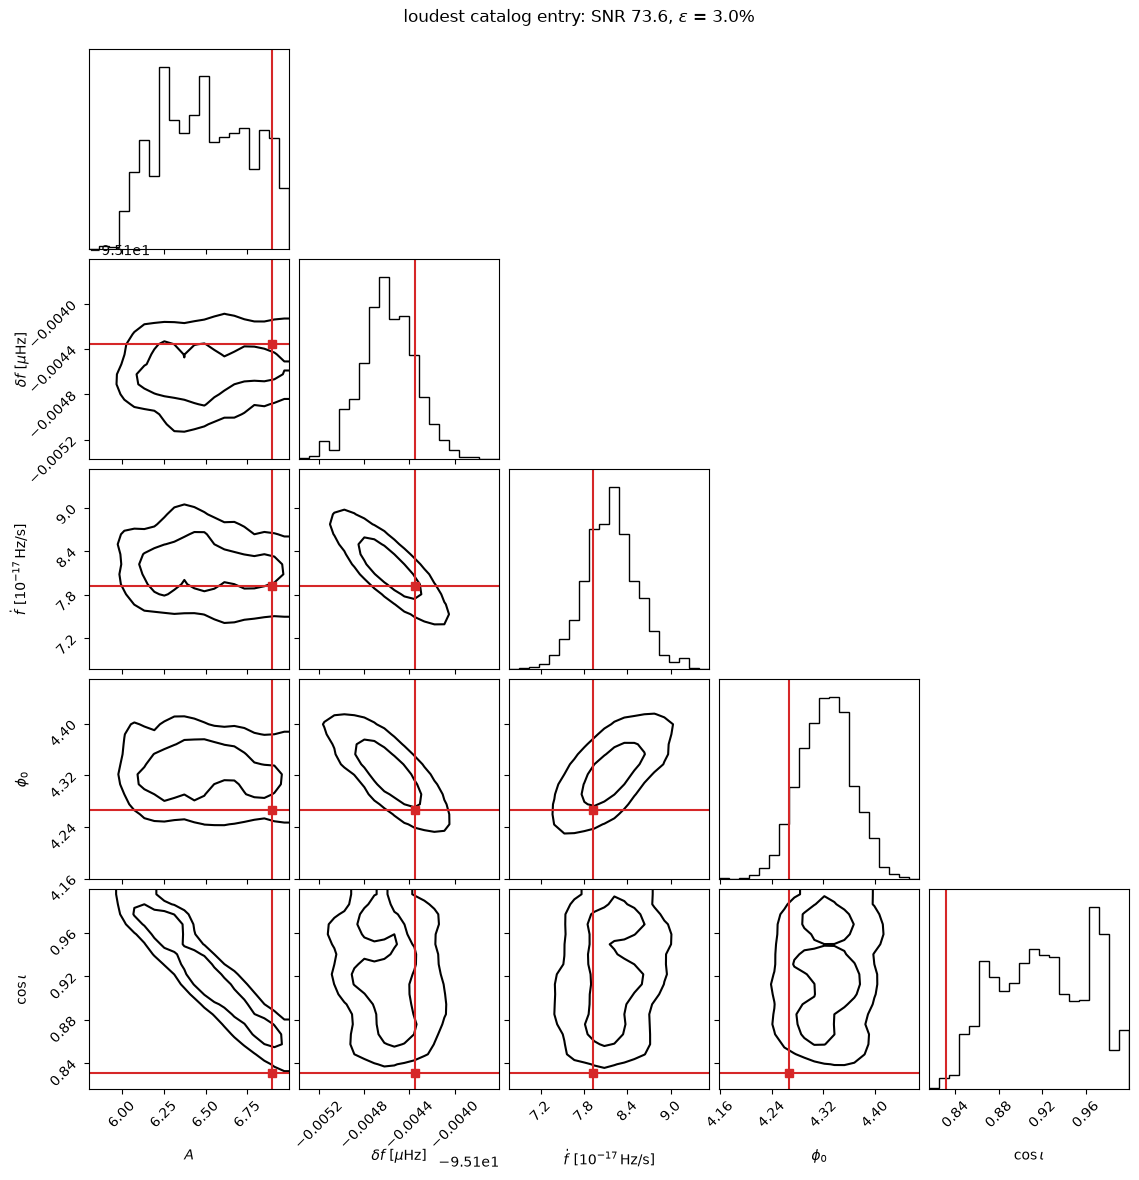

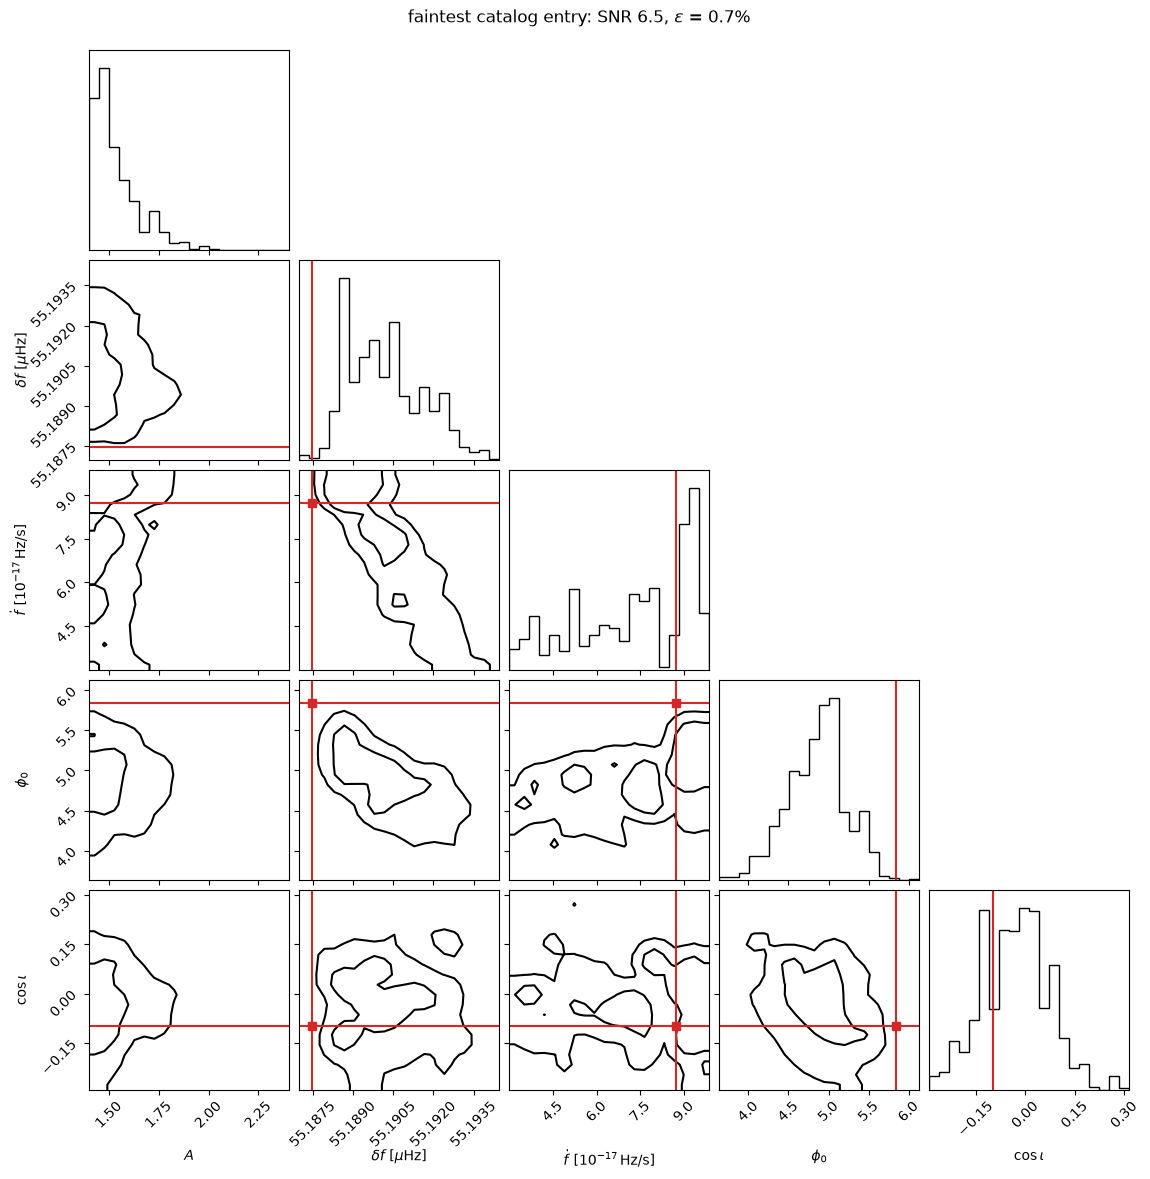

In [12]:
LABELS_W = [r"$A$", r"$\delta f\ [\mu{\rm Hz}]$", r"$\dot f\ [10^{-17}\,{\rm Hz/s}]$",
            r"$\phi_0$", r"$\cos\iota$"]
SCALE_W = np.array([1.0, 1e6, 1e17, 1.0, 1.0])

matched_rows = [r for r in catalog if r["cand"]["matched"] is not None]
row_loud = max(matched_rows, key=lambda r: r["snr"])
row_faint = min(matched_rows, key=lambda r: r["snr"])

for row, tag in [(row_loud, "loudest"), (row_faint, "faintest")]:
    truth = theta_true[row["cand"]["matched"]].cpu().numpy() * SCALE_W
    fig = corner.corner(row["samples"].cpu().numpy() * SCALE_W, labels=LABELS_W,
                        levels=(0.5, 0.9), smooth=1.0, plot_datapoints=False,
                        plot_density=False, truths=truth, truth_color="C3",
                        hist_kwargs={"density": True})
    fig.suptitle(f"{tag} catalog entry: SNR {row['snr']:.1f}, "
                 f"$\\epsilon$ = {row['eps']:.1%}", y=1.0)

A closing test of the whole pipeline: subtract the catalog's best-fit waveforms from the record
and look at what is left. The residual is consistent with the noise floor, plus the few faint
sources the catalog declined to claim.

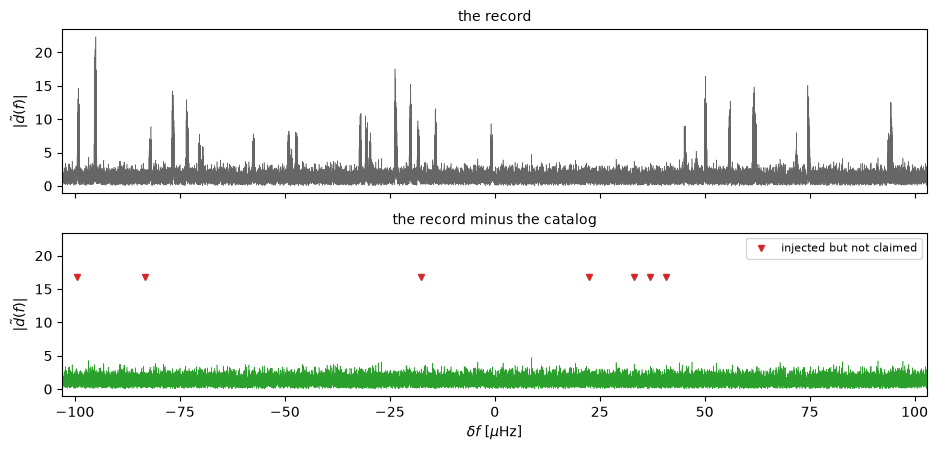

In [13]:
theta_fit = torch.stack([r["samples"].median(0).values for r in catalog])
recon = gbw.signal_wide(theta_fit).sum(0)
z_res = torch.complex((d - recon)[:gbw.N_WIDE], (d - recon)[gbw.N_WIDE:]).cpu().numpy()
spec_res = np.abs(np.fft.fftshift(np.fft.fft(z_res))) / np.sqrt(gbw.N_WIDE)

fig, axes = plt.subplots(2, 1, figsize=(9.5, 4.6), sharex=True, sharey=True)
axes[0].plot(f_axis, spec_data, lw=0.4, color="0.4")
axes[0].set_title("the record", fontsize=10)
axes[1].plot(f_axis, spec_res, lw=0.4, color="C2")
if missed.any():
    axes[1].plot(f_true[missed].cpu() * 1e6, np.full(int(missed.sum()), spec_data.max() * 0.75),
                 "v", color="C3", ms=5, label="injected but not claimed")
    axes[1].legend(fontsize=8)
axes[1].set_title("the record minus the catalog", fontsize=10)
axes[1].set_xlim(-103, 103)
axes[1].set_xlabel(r"$\delta f\ [\mu{\rm Hz}]$")
for ax in axes:
    ax.set_ylabel(r"$|\tilde d(f)|$")
plt.tight_layout()

---
# 5. Completeness, and the resolvability limit

<!-- *(~4 min)* -->

The selection function this catalog would ship with: detection probability against SNR, from the
matched truth. The transition sits where the noise-only calibration put it, and it is sharp,
because at fixed frequency resolution detectability here is almost purely an SNR statement.

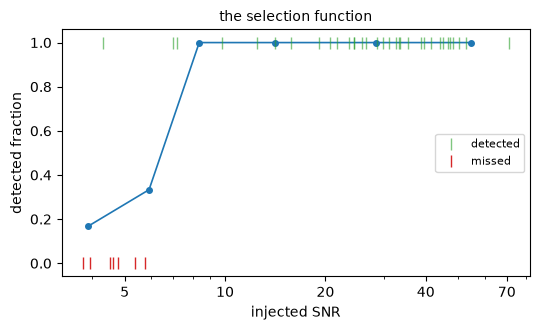

In [14]:
from matplotlib.ticker import FixedLocator, NullFormatter, ScalarFormatter

edges = np.array([3, 5, 7, 10, 20, 40, 75])
mids = np.sqrt(edges[:-1] * edges[1:])
s_np, det_np = snr_true.cpu().numpy(), detected.cpu().numpy()
frac = [det_np[(s_np >= a) & (s_np < b)].mean() if ((s_np >= a) & (s_np < b)).any() else np.nan
        for a, b in zip(edges[:-1], edges[1:])]

plt.figure(figsize=(5.5, 3.4))
plt.semilogx(mids, frac, "o-", color="C0", lw=1.2, ms=4)
plt.plot(s_np[det_np], np.ones(int(det_np.sum())), "|", color="C2", ms=8, alpha=0.6,
         label="detected")
plt.plot(s_np[~det_np], np.zeros(int((~det_np).sum())), "|", color="C3", ms=8, label="missed")
ax = plt.gca()
ax.xaxis.set_major_locator(FixedLocator([3, 5, 10, 20, 40, 70]))
ax.xaxis.set_major_formatter(ScalarFormatter())
ax.xaxis.set_minor_formatter(NullFormatter())
plt.xlabel("injected SNR"); plt.ylabel("detected fraction")
plt.ylim(-0.06, 1.06)
plt.title("the selection function", fontsize=10)
plt.legend(fontsize=8, loc="center right"); plt.tight_layout()

What about the sources that share a band? Check the catalog table: nothing looks wrong, and that
is correct behavior. At these separations the neighbor's frequency lies far outside the tile's
template family, so its power barely overlaps any waveform the model can propose, and both the
posterior and $\epsilon$ come through clean. Overlap in the band is not yet confusion. Confusion
begins when two sources approach within the posterior's own frequency scale, inside one tile,
where no template can tell one binary from two. Stephen's exercise 7(b) met this on a single
event; here is the same experiment run against the loudest catalog entry.

In [15]:
i_loud = row_loud["cand"]["matched"]
k_loud = row_loud["cand"]["k_peak"]
intruder = theta_true[i_loud].clone()[None]
intruder[0, 0] *= 0.6                    # fainter than the catalog source ...
intruder[0, 1] += 1.5e-8                 # ... 15 nHz away: same tile, unresolvable
intruder[0, 3], intruder[0, 4] = 2.0, -0.3
d_confused = d + gbw.signal_wide(intruder)[0]

p_clean = gbc.tile_posterior(flow, d, k_loud, n=8000)
p_confused = gbc.tile_posterior(flow, d_confused, k_loud, n=8000)
print(f"catalog source SNR {snr_true[i_loud]:.1f}; intruder SNR {gbc.snr(intruder)[0]:.1f}, "
      f"15 nHz away")
print(f"clean tile:    eps {p_clean['eps']:.1e}   ln B {p_clean['log_B']:.0f}")
print(f"confused tile: eps {p_confused['eps']:.1e}   ln B {p_confused['log_B']:.0f}")

catalog source SNR 70.9; intruder SNR 22.3, 15 nHz away
clean tile:    eps 3.0e-02   ln B 2678
confused tile: eps 1.2e-04   ln B 2577


The detection is untouched, the evidence still towers, but $\epsilon$ collapses by more than two
orders of magnitude. The proposal is a *single*-source model; the exact likelihood knows there
are two, and $\epsilon$ is where that disagreement is priced. The pipeline cannot repair this
entry, but it refuses to certify it, and that refusal is what makes the rest of the catalog
trustworthy. Importance sampling does not improve the model; it tells you, per event, whether
the model was enough.

---
# 6. Exercises, and what Part 2 must repair

**Exercises**, roughly in order of effort:

- **(a) Crowd it.** Set `n_sources=100` in the settings cell and re-run. Watch the completeness
  curve (it should barely move, since detection is per-tile), the false-alarm count at the same
  threshold, and how many catalog entries now share a band.
- **(b) Earn the threshold.** Lower `THRESHOLD` toward and below the noise-only maximum and
  count false alarms as it drops. This traces the catalog's ROC curve; the noise-only scan
  handed you the operating point for free.
- **(c) Price the band-limited likelihood.** `gbc.tile_posterior` takes `likelihood="band"` or
  `"full"`. Compare the two sets of log weights on one loud candidate (the module's self-test
  shows how); the difference should be a near-constant offset well under a nat.
- **(d) Map the resolvability limit.** Section 5 put the intruder 15 nHz from the source. Sweep
  the separation from 5 nHz to 1 $\mu$Hz and plot $\epsilon$ against it. Where does the
  single-source model recover, and how does that scale compare with the posterior width in
  $\delta f$ and with the tile?

**What Part 2 must repair.** The pipeline scales to crowded data, but the model is still
single-source, and importance sampling can only flag that, not fix it. The white-noise floor is
the other loose end: in the real band, the noise below threshold *is* a population of unresolved
binaries, colored and non-Gaussian. Part 2 rebuilds the training distribution to match, drawing
background binaries into every training signal: across the full retained band, fainter and
louder than the labelled source alike, with *loudest-in-tile* as the labelling convention that
keeps the target well defined. The network then learns to marginalize over the confusion it will
actually meet. Same architecture, same scan, different assumed world.